# Antenna Radiation Pattern — RX Lens Profile deep-dive

## Background

This notebook is a **dedicated, standalone deep-dive** on one piece of
`Setup_20mx20m_lens_9x9_Patch_randomCom.ipynb`: section **"7d. RX Antenna Profile — review all
scenarios before the main loop"**. That section, in the source notebook, only loops over
`SIMULATION_CONFIGS` and calls a generic `show_antenna_profile()` (efficiency + one 3D plot +
1 boresight number) for each **unique** RX farfield CSV, right before the expensive 9x `PathSolver`
main loop. It answers "does each lens angle load OK and roughly point where expected?" but doesn't
compare angles side-by-side or check the symmetry assumption baked into the RX configuration.

This notebook reuses the exact same loader (`HFSSPattern`) and analysis primitives
(`pattern_peak_local`, `compute_gain`) from the source notebook, but goes further:

1. **Setup** — `HFSSPattern` loader + orientation utilities, copied verbatim from the source
   notebook (sections 1 & 2) so this notebook is self-contained.
2. **RX lens configuration** — the RX-relevant subset of `SIMULATION_CONFIGS` (section 5 of the
   source notebook), highlighting a detail worth calling out explicitly: the 9 scenarios
   (`-60..+60 deg`) only load **5 unique CSV files** (`0, m15, m30, m45, m60`) — the "+" scenarios
   reuse the same "m" (negative) CSV and instead flip `rx_orientation_deg`, rather than using the
   Phi-mirrored CSVs that section 4 of the source notebook (`mirror_farfield_csv`) actually builds
   on disk (`farfieldAntennaData/_mirrored/FarFieldData_p*.csv`). Both are valid ways to express a
   symmetric lens, but they are **two different mechanisms** — this notebook checks whether they
   agree.
3. **Per-lens-angle profile** — efficiency, directivity/gain, boresight (local *and* world frame),
   same as section 7d, plus a consolidated summary table.
4. **Cross-angle comparison** — a full 360° vertical X-Z cut and a horizontal gain cut overlaid
   across all lens angles on shared axes, to see the beam-steering trend at
   a glance — something a per-pattern loop can't show.
5. **Mirror-symmetry sanity check** — for each `|angle|` in `{15, 30, 45, 60}`, project the same
   local pattern through both the "+" and "-" `rx_orientation_deg` from `SIMULATION_CONFIGS` and
   verify the resulting world-frame boresight directions are indeed mirror images of each other.
6. **Discussion & open questions.**

⚠️ Uses the same placeholder RX positions/orientations as the source notebook — replace once the
real array geometry is available, same caveat as there.

## Transmitarray radiation-pattern acquisition model

The geometry below defines the feed, the $(m,n)$-th transmitarray element, and the observation direction used to assemble the far-field radiation pattern.

<div style="text-align:center">
  <img src="AntennaLensRadiationPatternAsset/TransmitArray_CoorSystem.PNG" alt="Transmitarray coordinate system for radiation-pattern acquisition" style="max-width:850px; width:100%; height:auto;">
</div>

For an $M\times N$ transmitarray, the complex far-field pattern is

$$
\begin{aligned}
E(\theta,\varphi)
&= \sum_{m=1}^{M}\sum_{n=1}^{N}
\cos^{q_e}(\theta)\,
\frac{\cos^{q_f}\!\left(\theta_f(m,n)\right)}
{\left|\vec{r}_{mn}-\vec{r}_{f}\right|} \\[4pt]
&\quad \times
\exp\!\left\{-jk\left(
\left|\vec{r}_{mn}-\vec{r}_{f}\right|
-\vec{r}_{mn}\cdot\hat{\boldsymbol{u}}
\right)\right\}
\left|T_{mn}\right|e^{j\psi_{mn}}.
\end{aligned}
$$

**Equation (2.5).**

Here, $\theta$ and $\varphi$ specify the observation direction $\hat{\boldsymbol{u}}$; $\vec r_f$ and $\vec r_{mn}$ are the feed and element position vectors; $\theta_f(m,n)$ is the feed-incidence angle at element $(m,n)$; $q_e$ and $q_f$ control the element and feed pattern factors; $k=2\pi/\lambda$ is the wavenumber; and $|T_{mn}|e^{j\psi_{mn}}$ is the complex transmission coefficient of the element. The total radiation pattern is obtained by coherently summing all element contributions, including distance attenuation and propagation phase.


In [11]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import drjit as dr, mitsuba as mi
from scipy.spatial.transform import Rotation as Rot

import sionna.rt as rt
from sionna.rt import AntennaPattern
from sionna.rt.utils import rotation_matrix

np.set_printoptions(precision=3, suppress=True)

### 3D visualization of the transmitarray acquisition geometry

The plot below is a geometric visualization of the coordinate-system illustration above. It shows the transmitarray aperture, feed illumination path, a selected $(m,n)$ element, the main beam, and an observation direction. The requested viewing limits are fixed to $X\in[-5,5]$, $Y\in[-30,20]$, and $Z\in[0,55]$.

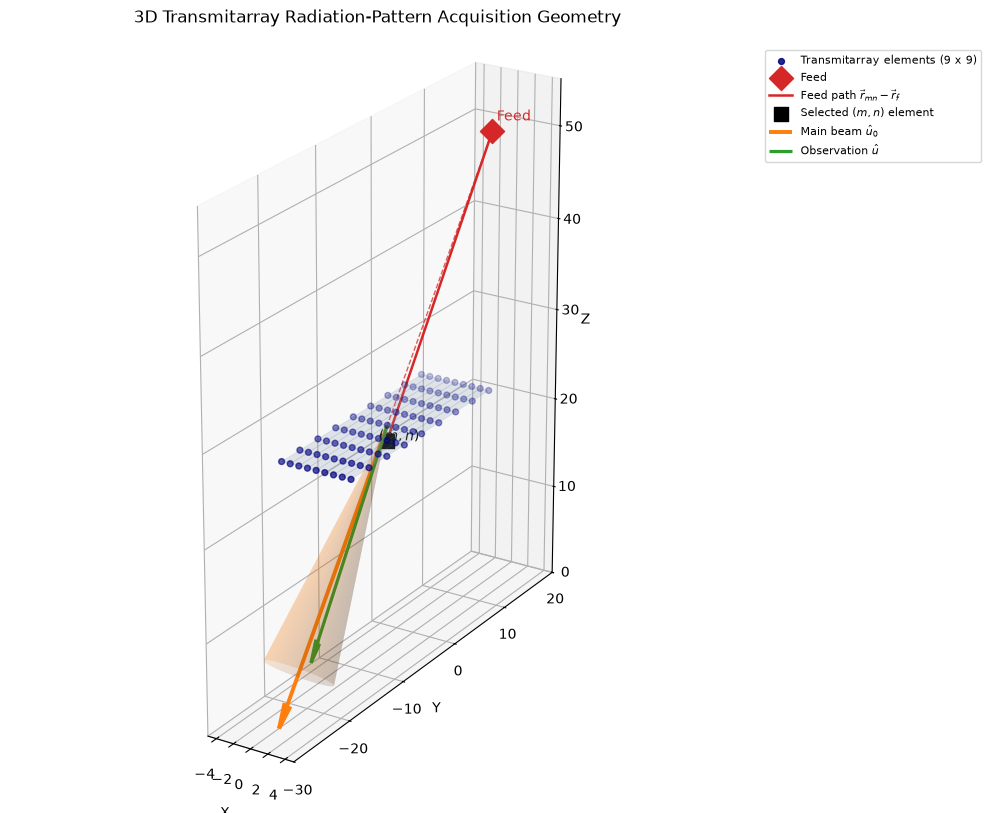

In [12]:
from pathlib import Path

# Requested 3D viewing limits
X_LIMITS = (-5.0, 5.0)
Y_LIMITS = (-30.0, 20.0)
Z_LIMITS = (0.0, 55.0)

# Illustrative transmitarray geometry; edit these parameters if measured dimensions are available.
M, N = 9, 9
TRANSMITARRAY_Z = 25.0
element_x = np.linspace(-4.0, 4.0, N)
element_y = np.linspace(-18.0, 8.0, M)
element_x_grid, element_y_grid = np.meshgrid(element_x, element_y)
element_z_grid = np.full_like(element_x_grid, TRANSMITARRAY_Z)

array_center = np.array([0.0, -5.0, TRANSMITARRAY_Z])
feed_position = np.array([0.0, 15.0, 50.0])
selected_element = np.array([element_x[6], element_y[3], TRANSMITARRAY_Z])

# The main beam continues away from the feed through the transmitarray.
main_beam_vector = np.array([0.0, -20.0, -25.0])
observation_vector = np.array([2.5, -18.0, -18.0])

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Transmitarray aperture and discrete radiating elements.
ax.plot_surface(
    element_x_grid, element_y_grid, element_z_grid,
    color="lightsteelblue", alpha=0.22, edgecolor="steelblue", linewidth=0.35,
)
ax.scatter(
    element_x_grid.ravel(), element_y_grid.ravel(), element_z_grid.ravel(),
    s=18, color="navy", alpha=0.85, label=f"Transmitarray elements ({M} x {N})",
)

# Feed and illumination rays.
ax.scatter(*feed_position, s=150, marker="D", color="tab:red", label="Feed")
ax.plot(
    [feed_position[0], selected_element[0]],
    [feed_position[1], selected_element[1]],
    [feed_position[2], selected_element[2]],
    color="tab:red", linewidth=1.8, label=r"Feed path $\vec{r}_{mn}-\vec{r}_f$",
)
ax.plot(
    [feed_position[0], array_center[0]],
    [feed_position[1], array_center[1]],
    [feed_position[2], array_center[2]],
    color="tab:red", linewidth=1.0, linestyle="--", alpha=0.75,
)
ax.scatter(*selected_element, s=95, marker="s", color="black", label=r"Selected $(m,n)$ element")

# Transmitted main-beam arrow and observation-direction arrow.
ax.quiver(
    *array_center, *main_beam_vector,
    color="tab:orange", linewidth=2.8, arrow_length_ratio=0.08, label=r"Main beam $\hat{u}_0$",
)
ax.quiver(
    *array_center, *observation_vector,
    color="tab:green", linewidth=2.3, arrow_length_ratio=0.09, label=r"Observation $\hat{u}$",
)

# A translucent cone provides an intuitive 3D representation of the main radiation lobe.
beam_length = np.linalg.norm(main_beam_vector)
beam_axis = main_beam_vector / beam_length
beam_basis_1 = np.array([1.0, 0.0, 0.0])
beam_basis_2 = np.cross(beam_axis, beam_basis_1)
beam_basis_2 /= np.linalg.norm(beam_basis_2)
beam_distance = np.linspace(0.0, 0.82 * beam_length, 36)
beam_azimuth = np.linspace(0.0, 2.0 * np.pi, 48)
beam_radius = 0.14 * beam_distance
beam_points = (
    array_center[:, None, None]
    + beam_axis[:, None, None] * beam_distance[None, :, None]
    + beam_radius[None, :, None]
      * (
          beam_basis_1[:, None, None] * np.cos(beam_azimuth)[None, None, :]
          + beam_basis_2[:, None, None] * np.sin(beam_azimuth)[None, None, :]
        )
)
ax.plot_surface(
    beam_points[0], beam_points[1], beam_points[2],
    color="tab:orange", alpha=0.16, linewidth=0, shade=True,
)

# Labels and the exact axis limits requested.
ax.text(*(feed_position + np.array([0.2, 0.5, 1.0])), "Feed", color="tab:red", fontsize=10)
ax.text(*(selected_element + np.array([0.2, -1.8, 0.7])), r"$(m,n)$", color="black", fontsize=10)
ax.set_xlim(*X_LIMITS)
ax.set_ylim(*Y_LIMITS)
ax.set_zlim(*Z_LIMITS)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect((X_LIMITS[1]-X_LIMITS[0], Y_LIMITS[1]-Y_LIMITS[0], Z_LIMITS[1]-Z_LIMITS[0]))
ax.set_title("3D Transmitarray Radiation-Pattern Acquisition Geometry", pad=16)
ax.view_init(elev=23, azim=-58)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
plt.tight_layout()

# Save the 3D graph and its reusable coordinate data in a dedicated folder.
geometry_output_dir = Path("AntennaLensRadiationPatternOutput/transmitarray_3d")
geometry_data_dir = geometry_output_dir / "data"
geometry_figure_dir = geometry_output_dir / "figures"
geometry_data_dir.mkdir(parents=True, exist_ok=True)
geometry_figure_dir.mkdir(parents=True, exist_ok=True)

element_geometry_data = pd.DataFrame({
    "m": np.repeat(np.arange(1, M + 1), N),
    "n": np.tile(np.arange(1, N + 1), M),
    "x": element_x_grid.ravel(),
    "y": element_y_grid.ravel(),
    "z": element_z_grid.ravel(),
})
element_geometry_data.to_csv(geometry_data_dir / "transmitarray_elements.csv", index=False)

geometry_reference_data = pd.DataFrame([
    {"name": "array_center", "kind": "point", "x": array_center[0], "y": array_center[1], "z": array_center[2], "dx": 0.0, "dy": 0.0, "dz": 0.0},
    {"name": "feed", "kind": "point", "x": feed_position[0], "y": feed_position[1], "z": feed_position[2], "dx": 0.0, "dy": 0.0, "dz": 0.0},
    {"name": "selected_element", "kind": "point", "x": selected_element[0], "y": selected_element[1], "z": selected_element[2], "dx": 0.0, "dy": 0.0, "dz": 0.0},
    {"name": "main_beam", "kind": "vector", "x": array_center[0], "y": array_center[1], "z": array_center[2], "dx": main_beam_vector[0], "dy": main_beam_vector[1], "dz": main_beam_vector[2]},
    {"name": "observation", "kind": "vector", "x": array_center[0], "y": array_center[1], "z": array_center[2], "dx": observation_vector[0], "dy": observation_vector[1], "dz": observation_vector[2]},
])
geometry_reference_data.to_csv(geometry_data_dir / "geometry_references.csv", index=False)
geometry_figure_path = geometry_figure_dir / "transmitarray_acquisition_geometry_3d.png"
fig.savefig(geometry_figure_path, dpi=220, bbox_inches="tight")
print(f"Saved 3D geometry data : {geometry_data_dir}")
print(f"Saved 3D geometry graph: {geometry_figure_path}")
plt.show()

## 1. HFSS antenna pattern loader

Copied verbatim from `Setup_20mx20m_lens_9x9_Patch_randomCom.ipynb`, section 1 — parses an HFSS
farfield CSV (`Theta/Phi/GainTheta/GainPhi/rETheta/rEPhi`, optionally filtered by `Freq` and extra
parameter columns such as `theta_foc_1`) into a Sionna `AntennaPattern`, with an optional one-shot
rotation (`rot_deg`) applied to the raw grid data right after loading (used here to convert the
HFSS convention, z-normal boresight, into Sionna's local-x boresight convention: `HFSS_ROT_DEG =
(90, 90, 0)`).

In [13]:
class HFSSPattern(AntennaPattern):
    def __init__(self, csv_file, freq_ghz=None, param_filters=None,
                 phi_offset_deg=0.0, rot_deg=(0., 0., 0.), polarization="V"):
        super().__init__()
        df = pd.read_csv(csv_file)
        df.columns = [c.strip().strip('"') for c in df.columns]
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
        col = lambda key: next(c for c in df.columns if key.lower() in c.lower())
        if freq_ghz is not None:
            df = df[np.isclose(df[col("Freq")], freq_ghz)]
        if param_filters:
            for k, v in param_filters.items():
                df = df[np.isclose(df[col(k)], v)]
        assert len(df) > 0, "No data left after filtering — check freq/parameter"
        th = np.sort(df[col("Theta [")].unique()); ph = np.sort(df[col("Phi [")].unique())
        piv = lambda c: df.pivot_table(index=col("Theta ["), columns=col("Phi ["), values=c).values
        Ctm = np.sqrt(10**(piv(col("GainTheta"))/10.))*np.exp(1j*np.deg2rad(piv(col("rETheta"))))
        Cpm = np.sqrt(10**(piv(col("GainPhi"))/10.)) *np.exp(1j*np.deg2rad(piv(col("rEPhi"))))
        # === rotation via angle, right after the CSV is read (numpy, one-shot) ===
        R = Rot.from_euler("ZYX", np.deg2rad(rot_deg)).as_matrix()
        if not np.allclose(R, np.eye(3)):
            Ctm, Cpm = self._rotate_data(Ctm, Cpm, th, ph, R)
        self._t0, self._dt, self._nt = float(th[0]), float(th[1]-th[0]), len(th)
        self._p0, self._dp, self._np = float(ph[0]), float(ph[1]-ph[0]), len(ph)
        self._phi_off = float(np.deg2rad(phi_offset_deg))
        f32 = lambda x: mi.Float(np.ascontiguousarray(x, np.float32).ravel())
        self._buf = [f32(Ctm.real), f32(Ctm.imag), f32(Cpm.real), f32(Cpm.imag)]
        slants = {"V": [0.], "H": [90.], "VH": [0., 90.], "cross": [-45., 45.]}[polarization]
        self.patterns = [(lambda th_, ph_, z=np.deg2rad(s): self._pattern(th_, ph_, z))
                         for s in slants]

    @staticmethod
    def _rotate_data(Ct, Cp, th_deg, ph_deg, R):
        """Resample the grid pattern: the new pattern in direction v = the old pattern in direction
        u=R^T v, with the field vectors also rotated by R. All numpy, one-shot.
        NB: intentionally without np.matmul/@ — numpy BLAS in this env used to crash (delay-load
        DLL bug)."""
        T, P = np.meshgrid(np.deg2rad(th_deg), np.deg2rad(ph_deg), indexing="ij")
        st, ct = np.sin(T), np.cos(T); sp, cp = np.sin(P), np.cos(P)
        vx, vy, vz = st*cp, st*sp, ct
        ux = R[0,0]*vx + R[1,0]*vy + R[2,0]*vz
        uy = R[0,1]*vx + R[1,1]*vy + R[2,1]*vz
        uz = R[0,2]*vx + R[1,2]*vy + R[2,2]*vz
        thc = np.arccos(np.clip(uz, -1., 1.))
        phc = np.arctan2(uy, ux)
        dt = th_deg[1]-th_deg[0]; dp = ph_deg[1]-ph_deg[0]; nper = len(ph_deg)-1.0
        ft = np.clip((np.rad2deg(thc)-th_deg[0])/dt, 0., len(th_deg)-1.001)
        fp = (np.rad2deg(phc)-ph_deg[0])/dp
        fp = fp - np.floor(fp/nper)*nper
        i0 = np.floor(ft).astype(int); j0 = np.floor(fp).astype(int)
        wt = ft-i0; wp = fp-j0
        samp = lambda A: ((1-wt)*(1-wp)*A[i0,j0] + (1-wt)*wp*A[i0,j0+1]
                        +  wt*(1-wp)*A[i0+1,j0] +  wt*wp*A[i0+1,j0+1])
        Cts, Cps = samp(Ct), samp(Cp)
        sthc, cthc = np.sin(thc), np.cos(thc); sphc, cphc = np.sin(phc), np.cos(phc)
        ex = Cts*cthc*cphc - Cps*sphc
        ey = Cts*cthc*sphc + Cps*cphc
        ez = -Cts*sthc
        Ex = R[0,0]*ex + R[0,1]*ey + R[0,2]*ez
        Ey = R[1,0]*ex + R[1,1]*ey + R[1,2]*ez
        Ez = R[2,0]*ex + R[2,1]*ey + R[2,2]*ez
        Ct_new = Ex*ct*cp + Ey*ct*sp - Ez*st
        Cp_new = -Ex*sp + Ey*cp
        return Ct_new, Cp_new

    def _pattern(self, theta, phi, zeta=0.0):
        ft = dr.clip((theta*180.0/dr.pi - self._t0)/self._dt, 0.0, self._nt-1.001)
        nint = self._np - 1.0
        fp = ((phi - self._phi_off)*180.0/dr.pi - self._p0)/self._dp
        fp = fp - dr.floor(fp/nint)*nint
        i0 = mi.Int32(dr.floor(ft)); j0 = mi.Int32(dr.floor(fp))
        wt = ft - mi.Float(i0);      wp = fp - mi.Float(j0)
        idx = [i0*self._np+j0, i0*self._np+j0+1, (i0+1)*self._np+j0, (i0+1)*self._np+j0+1]
        w = [(1-wt)*(1-wp), (1-wt)*wp, wt*(1-wp), wt*wp]
        v = [sum(wi*dr.gather(mi.Float, bb, ix) for wi, ix in zip(w, idx)) for bb in self._buf]
        Ctr, Cti, Cpr, Cpi = v
        cz, sz = float(np.cos(zeta)), float(np.sin(zeta))
        return (mi.Complex2f(cz*Ctr - sz*Cpr, cz*Cti - sz*Cpi),
                mi.Complex2f(sz*Ctr + cz*Cpr, sz*Cti + cz*Cpi))


def make_hfss_factory(csv_file, **kw):
    def factory(*, polarization="V", polarization_model=None):
        return HFSSPattern(csv_file, polarization=polarization, **kw)
    return factory

## 2. Orientation utilities

Copied from the source notebook, section 2 — `R_of` turns a Sionna `orientation` (radians,
`[alpha, beta, gamma]`) into a world-frame rotation matrix; `boresight_world` projects a
pattern's LOCAL peak-gain direction into the WORLD frame given a device orientation. Used later in
section 6 (mirror-symmetry check).

In [14]:
def R_of(o):
    return np.array(rotation_matrix(mi.Point3f(*[float(v) for v in o]))).reshape(3, 3)

def boresight_world(orientation, v_local):
    """Predict the direction of any local vector after being rotated by orientation."""
    R = np.array(rotation_matrix(mi.Point3f(*[float(v) for v in orientation]))).reshape(3, 3)
    return R @ np.asarray(v_local, float)

## 3. RX lens configuration

The RX-relevant subset of `SIMULATION_CONFIGS` (source notebook, section 5) — `rx_position` is
dropped here since this notebook is only about the **pattern**, not the full scene/channel.

`HFSS_ROT_DEG = (90, 90, 0)` is the same HFSS -> Sionna convention rotation used everywhere else in
this project (`Setup_20mx20m_9x1_Lens.ipynb`, the source notebook, etc.).

Note the CSV reuse: `Simul_+15deg`/`Simul_-15deg` both load `FarFieldData_m15deg_detailFreq.csv`
(same for `±30`, `±60`) — the "+"/"-" distinction there lives entirely in `rx_orientation_deg`,
not the data. **`±45` is different**: both load `FarFieldData_m45deg_detailFreq.csv` too, but with
**opposite `theta_foc_1` filters** (`-45` vs `+45`) selecting two genuinely different data subsets
from the *same* CSV — so counting by CSV file undercounts: there are **6 unique (csv,
param_filters) patterns behind the 9 scenarios, not 5.**

⚠️ **This matters**: the source notebook's section 7d cache (`_shown_rx_profiles`) is keyed by
`csv_path` alone. Since `Simul_+45deg` is processed before `Simul_-45deg` in `SIMULATION_CONFIGS`
and both share the same `csv_path`, the cache marks the path "seen" after `+45deg` — so
**`Simul_-45deg`'s actual pattern (`theta_foc_1=+45`) is never loaded or reviewed in section 7d**
(nor in the main loop's copy of the same cache, section 8), even though its gain/efficiency/peak
direction genuinely differ from `+45deg`'s. This notebook keys by `(csv_path, param_filters)`
instead, precisely so this doesn't happen — see section 5. (The `SIMULATION_CONFIGS` *values*
themselves turn out fine — section 7 confirms `±45deg` mirrors correctly once the right filter is
actually loaded; it's specifically the review/cache step that has the blind spot.)

In [15]:
FREQ_GHZ = 38
HFSS_ROT_DEG = (0., 90., 0.)

# RX-relevant subset of SIMULATION_CONFIGS (source notebook, section 5) -- rx_position dropped,
# everything else copied as-is.
RX_LENS_SCENARIOS = [
    {"name": "Simul_+60deg", "rx_orientation_deg": [-90, -90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m60deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": 60},
    {"name": "Simul_+45deg", "rx_orientation_deg": [-90, 90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv",
     "rx_farfield_param_filters": {"theta_foc_1": -45}, "rx_lens_angle_deg": 45},
    {"name": "Simul_+30deg", "rx_orientation_deg": [-90, -90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m30deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": 30},
    {"name": "Simul_+15deg", "rx_orientation_deg": [-90, -90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m15deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": 15},
    {"name": "Simul_+0deg", "rx_orientation_deg": [-90, -90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_0deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": 0},
    {"name": "Simul_-15deg", "rx_orientation_deg": [-90, 90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m15deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": -15},
    {"name": "Simul_-30deg", "rx_orientation_deg": [-90, 90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m30deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": -30},
    {"name": "Simul_-45deg", "rx_orientation_deg": [-90, 90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv",
     "rx_farfield_param_filters": {"theta_foc_1": 45}, "rx_lens_angle_deg": -45},
    {"name": "Simul_-60deg", "rx_orientation_deg": [-90, 90, 0.0],
     "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m60deg_detailFreq.csv",
     "rx_farfield_param_filters": None, "rx_lens_angle_deg": -60},
]

def filt_key(cfg):
    pf = cfg["rx_farfield_param_filters"]
    return tuple(sorted(pf.items())) if pf else None

def pat_key(cfg):
    return (cfg["rx_farfield_csv"], filt_key(cfg))

_unique_csv = {cfg["rx_farfield_csv"] for cfg in RX_LENS_SCENARIOS}

_seen_keys = set()
UNIQUE_RX_PATTERNS = []
for cfg in RX_LENS_SCENARIOS:
    k = pat_key(cfg)
    if k in _seen_keys:
        continue
    _seen_keys.add(k)
    UNIQUE_RX_PATTERNS.append(cfg)

print(f"{len(RX_LENS_SCENARIOS)} RX scenarios -> {len(_unique_csv)} unique CSV files, "
      f"{len(UNIQUE_RX_PATTERNS)} unique (csv, param_filters) patterns:")
for cfg in UNIQUE_RX_PATTERNS:
    print(f"  {cfg['name']:16s} angle={cfg['rx_lens_angle_deg']:+4d} deg  "
          f"filters={cfg['rx_farfield_param_filters']}  csv={cfg['rx_farfield_csv']}")

# What the SOURCE notebook's csv_path-only cache would actually show (section 7d/8):
_source_cache_seen = set()
_source_would_skip = []
for cfg in RX_LENS_SCENARIOS:
    if cfg["rx_farfield_csv"] in _source_cache_seen:
        _source_would_skip.append(cfg["name"])
        continue
    _source_cache_seen.add(cfg["rx_farfield_csv"])
if _source_would_skip:
    print(f"\n  -> with the source notebook's csv_path-only cache, {_source_would_skip} would "
          f"NEVER be reviewed in section 7d/8. Harmless for the 15/30/60 deg entries (same "
          f"param_filters as their '+' counterpart -- identical pattern, only orientation "
          f"differs, which isn't part of the antenna-profile review anyway). NOT harmless for "
          f"'Simul_-45deg': its param_filters={{'theta_foc_1': 45}} selects genuinely different "
          f"data than 'Simul_+45deg' ({{'theta_foc_1': -45}}) -- see section 5/8.")

9 RX scenarios -> 5 unique CSV files, 6 unique (csv, param_filters) patterns:
  Simul_+60deg     angle= +60 deg  filters=None  csv=farfieldAntennaData/FarFieldData_m60deg_detailFreq.csv
  Simul_+45deg     angle= +45 deg  filters={'theta_foc_1': -45}  csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv
  Simul_+30deg     angle= +30 deg  filters=None  csv=farfieldAntennaData/FarFieldData_m30deg_detailFreq.csv
  Simul_+15deg     angle= +15 deg  filters=None  csv=farfieldAntennaData/FarFieldData_m15deg_detailFreq.csv
  Simul_+0deg      angle=  +0 deg  filters=None  csv=farfieldAntennaData/FarFieldData_0deg_detailFreq.csv
  Simul_-45deg     angle= -45 deg  filters={'theta_foc_1': 45}  csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv

  -> with the source notebook's csv_path-only cache, ['Simul_-15deg', 'Simul_-30deg', 'Simul_-45deg', 'Simul_-60deg'] would NEVER be reviewed in section 7d/8. Harmless for the 15/30/60 deg entries (same param_filters as their '+' counterpart --

## 4. Pattern analysis utilities

- `pattern_peak_local` (copied from the source notebook, section 7) — brute-force search over a
  `theta x phi` grid for the global peak gain direction, in the pattern's LOCAL frame.
- `pattern_cuts` (new here) — returns a **full 360° vertical cut** in the X-Z plane and the
  horizontal cut `G(theta=pi/2, phi)` in the X-Y plane. The vertical angle `alpha` is defined as
  `0° -> +z`, `90° -> +x`, `180° -> -z`, and `270° -> -x`; internally, the second half of the
  circle switches from `phi=0` to `phi=pi`. The raw arrays let section 6 overlay all lens angles
  on the same axes.
- `yz_plane_cut` (new here) — a **third** cut that `show()` doesn't provide at all: a full 360°
  slice through the **Y-Z plane** (`x=0`), parameterized by a single angle `alpha` where
  `alpha=0 -> +z`, `alpha=90° -> +y`, `alpha=180° -> -z`, `alpha=270° -> -y`. Internally this maps
  to `(theta, phi) = (arccos(cos(alpha)), ±90°)` (`+90°` for `sin(alpha) >= 0`, `-90°` otherwise)
  so it can reuse `_total_gain`. Section 6b uses this for a Y-Z view across all lens angles.

In [16]:
def pattern_peak_local(pattern_obj, n_theta=91, n_phi=181):
    theta = np.linspace(0., np.pi, n_theta, dtype=np.float32)
    phi = np.linspace(-np.pi, np.pi, n_phi, dtype=np.float32)
    T, P = np.meshgrid(theta, phi, indexing="ij")
    Tf, Pf = mi.Float(T.ravel()), mi.Float(P.ravel())
    g_tot = np.zeros(T.size)
    for port in pattern_obj.patterns:
        c_t, c_p = port(Tf, Pf)
        g_tot = g_tot + np.array(c_t.real)**2 + np.array(c_t.imag)**2 \
                       + np.array(c_p.real)**2 + np.array(c_p.imag)**2
    i = int(np.argmax(g_tot))
    t_pk, p_pk = float(T.ravel()[i]), float(P.ravel()[i])
    v_local = np.array([np.sin(t_pk)*np.cos(p_pk), np.sin(t_pk)*np.sin(p_pk), np.cos(t_pk)])
    g_db = 10.*np.log10(g_tot[i] + 1e-15)
    return v_local, g_db, np.rad2deg(t_pk), np.rad2deg(p_pk)


def _total_gain(pattern_obj, theta, phi):
    g_tot = dr.zeros(mi.Float, len(theta))
    for port in pattern_obj.patterns:
        c_t, c_p = port(theta, phi)
        g_tot = g_tot + dr.abs(c_t)**2 + dr.abs(c_p)**2
    g = np.array(g_tot)
    return np.where(g == 0, 1e-12, g)


def pattern_cuts(pattern_obj, n=1000):
    """Full 360-deg vertical X-Z cut plus the horizontal X-Y cut.

    Vertical alpha convention: 0 -> +z, pi/2 -> +x, pi -> -z, 3pi/2 -> -x.
    Spherical coordinates use phi=0 on the +x half-plane and phi=pi on the -x half-plane.
    """
    alpha_v = np.linspace(0., 2*np.pi, n, endpoint=False, dtype=np.float32)
    x_v, z_v = np.sin(alpha_v), np.cos(alpha_v)
    theta_v = np.arccos(np.clip(z_v, -1., 1.)).astype(np.float32)
    phi_v = np.where(x_v >= 0., 0., np.pi).astype(np.float32)
    g_v_db = 10*np.log10(_total_gain(pattern_obj, mi.Float(theta_v), mi.Float(phi_v)))

    phi_h = np.linspace(-np.pi, np.pi, n, endpoint=False, dtype=np.float32)
    g_h_db = 10*np.log10(_total_gain(pattern_obj, np.pi/2*dr.ones(mi.Float, n), mi.Float(phi_h)))

    return alpha_v, g_v_db, phi_h, g_h_db


def yz_plane_cut(pattern_obj, n=1000):
    """Full 360-deg cut in the Y-Z plane (x=0). alpha=0 -> +z, alpha=pi/2 -> +y, alpha=pi -> -z,
    alpha=3pi/2 -> -y. Not one of the 2 cuts AntennaPattern.show() draws (those are x-z and x-y)."""
    alpha = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    y, z = np.sin(alpha), np.cos(alpha)
    theta = np.arccos(np.clip(z, -1., 1.)).astype(np.float32)
    phi = np.where(y >= 0, np.pi/2, -np.pi/2).astype(np.float32)
    g_db = 10*np.log10(_total_gain(pattern_obj, mi.Float(theta), mi.Float(phi)))
    return alpha, g_db

## 5. Per-lens-angle profile — efficiency, gain, boresight

Same content as section 7d of the source notebook (`compute_gain` + boresight per unique RX
farfield), plus the 2 cuts from `pattern_cuts` collected for the overlay in section 6, and a
consolidated summary table at the end (which the source notebook's loop doesn't build — it only
prints, scenario by scenario).

Loaded **once per unique `(csv, param_filters)` pattern** — all 6 (`UNIQUE_RX_PATTERNS` from
section 3), which correctly includes **both** `±45deg` variants (unlike the source notebook's
`csv_path`-only cache).

RX ANTENNA PROFILE -- per unique (csv, param_filters) pattern

--- Antenna profile: RX Simul_+60deg (farfieldAntennaData/FarFieldData_m60deg_detailFreq.csv, filters=None) ---
Directivity [dB]: 12.598  Gain [dB]: 12.210  Efficiency [%]: 91.451
[RX Simul_+60deg (farfieldAntennaData/FarFieldData_m60deg_detailFreq.csv, filters=None)] Local boresight: [ 0.615 -0.021  0.788] | peak 12.21 dB at theta=38 deg, phi=-2 deg


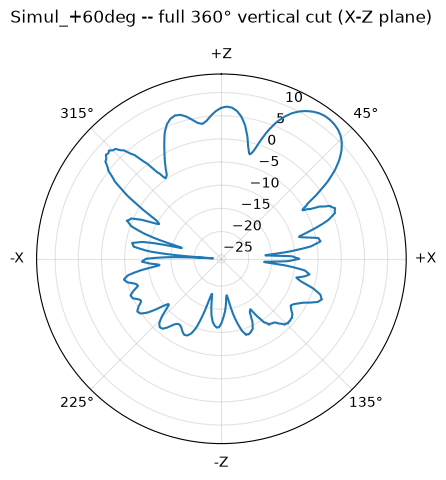

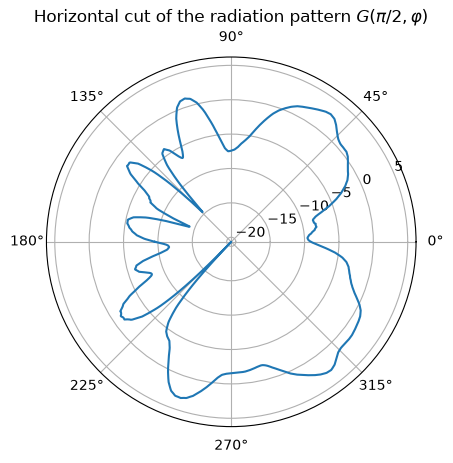

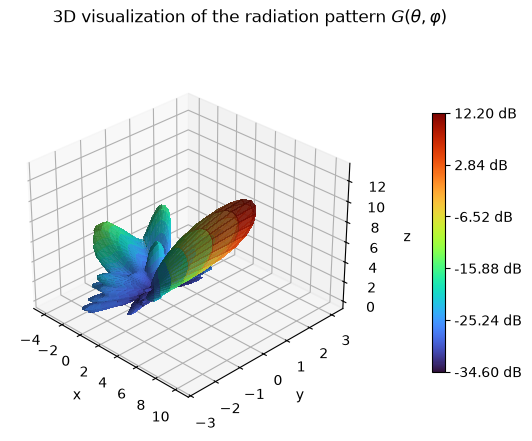


--- Antenna profile: RX Simul_+45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv, filters={'theta_foc_1': -45}) ---
Directivity [dB]: 14.664  Gain [dB]: 14.287  Efficiency [%]: 91.689
[RX Simul_+45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv, filters={'theta_foc_1': -45})] Local boresight: [ 0.827 -0.058 -0.559] | peak 14.29 dB at theta=124 deg, phi=-4 deg


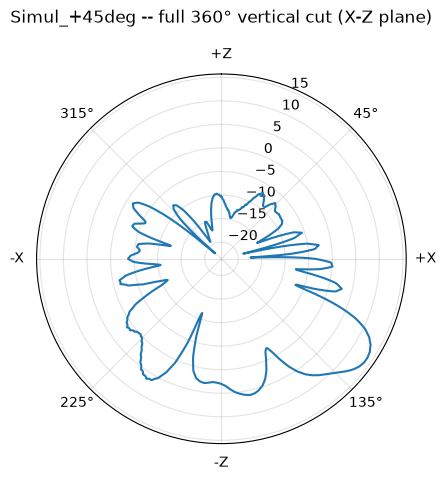

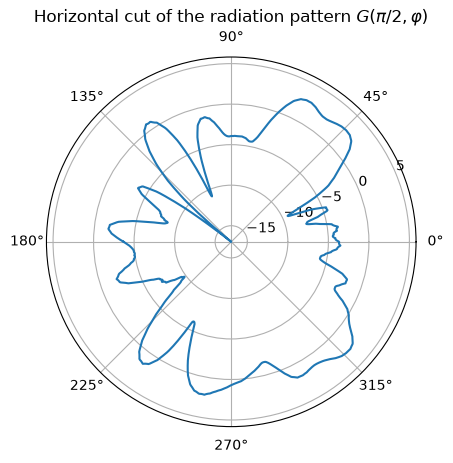

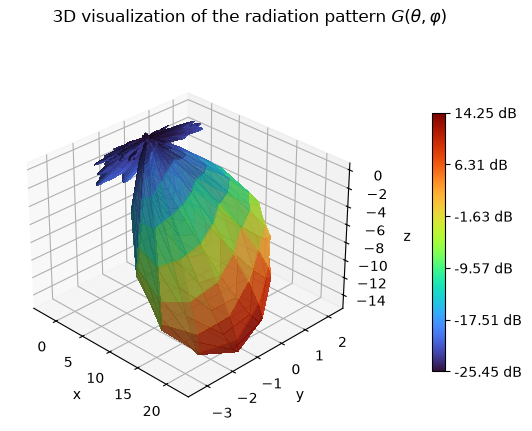


--- Antenna profile: RX Simul_+30deg (farfieldAntennaData/FarFieldData_m30deg_detailFreq.csv, filters=None) ---
Directivity [dB]: 16.031  Gain [dB]: 15.657  Efficiency [%]: 91.753
[RX Simul_+30deg (farfieldAntennaData/FarFieldData_m30deg_detailFreq.csv, filters=None)] Local boresight: [ 0.913 -0.032  0.407] | peak 15.66 dB at theta=66 deg, phi=-2 deg


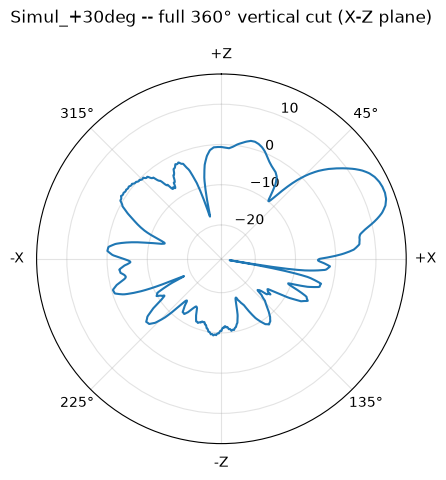

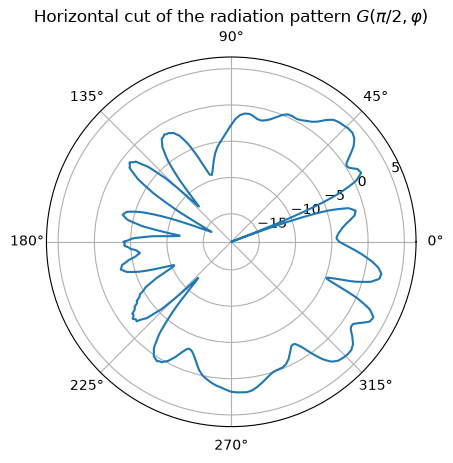

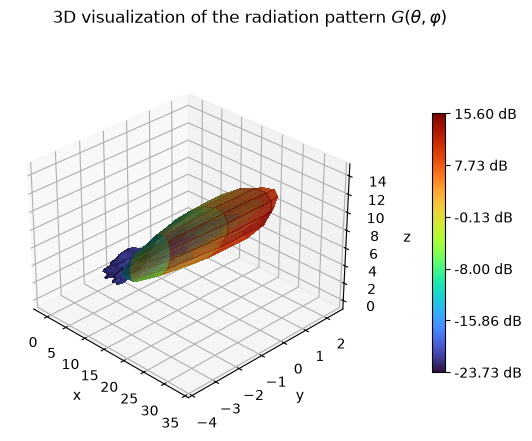


--- Antenna profile: RX Simul_+15deg (farfieldAntennaData/FarFieldData_m15deg_detailFreq.csv, filters=None) ---
Directivity [dB]: 16.977  Gain [dB]: 16.613  Efficiency [%]: 91.956
[RX Simul_+15deg (farfieldAntennaData/FarFieldData_m15deg_detailFreq.csv, filters=None)] Local boresight: [ 0.978 -0.034  0.208] | peak 16.62 dB at theta=78 deg, phi=-2 deg


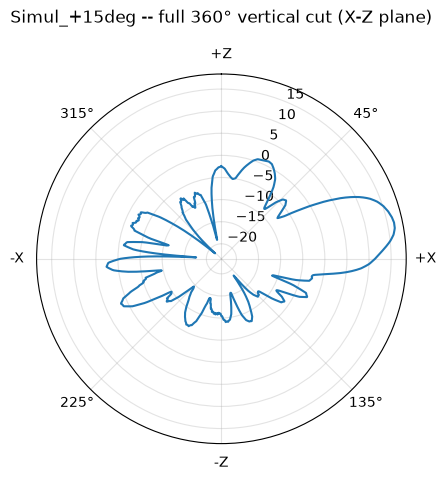

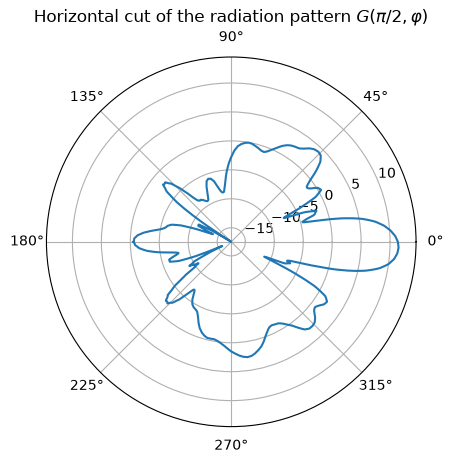

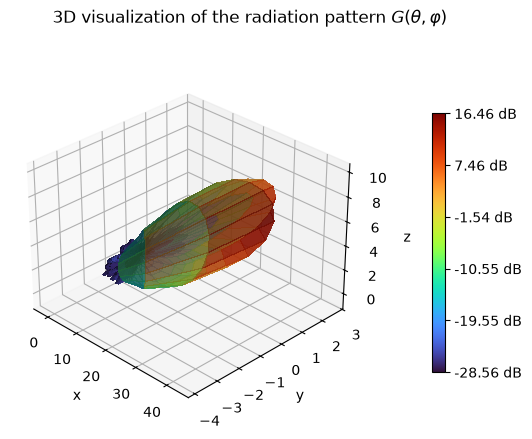


--- Antenna profile: RX Simul_+0deg (farfieldAntennaData/FarFieldData_0deg_detailFreq.csv, filters=None) ---
Directivity [dB]: 16.849  Gain [dB]: 16.509  Efficiency [%]: 92.456
[RX Simul_+0deg (farfieldAntennaData/FarFieldData_0deg_detailFreq.csv, filters=None)] Local boresight: [ 0.999 -0.035 -0.   ] | peak 16.51 dB at theta=90 deg, phi=-2 deg


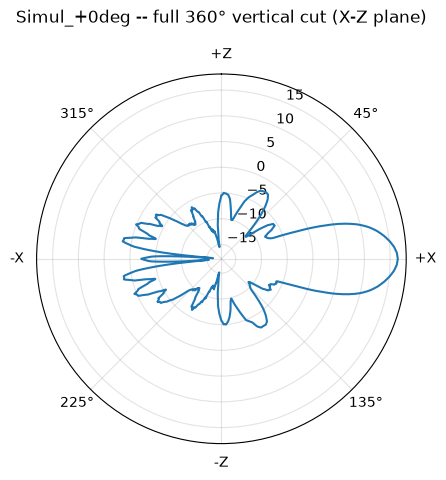

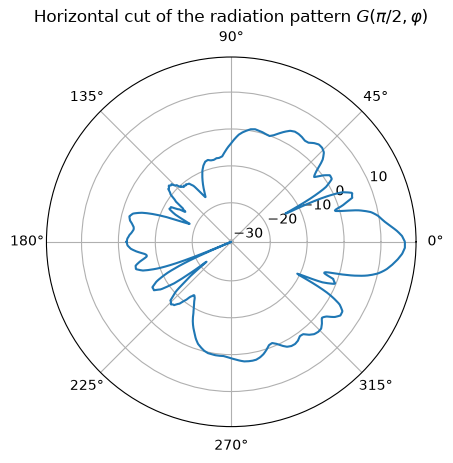

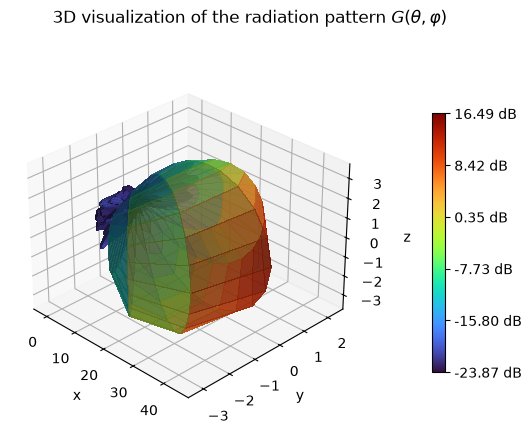


--- Antenna profile: RX Simul_-45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv, filters={'theta_foc_1': 45}) ---
Directivity [dB]: 14.594  Gain [dB]: 14.220  Efficiency [%]: 91.756
[RX Simul_-45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv, filters={'theta_foc_1': 45})] Local boresight: [ 0.827 -0.058  0.559] | peak 14.22 dB at theta=56 deg, phi=-4 deg


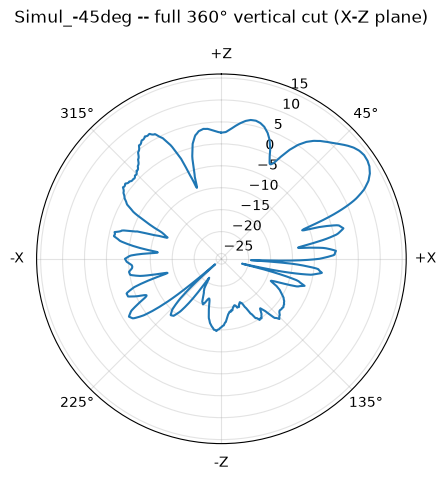

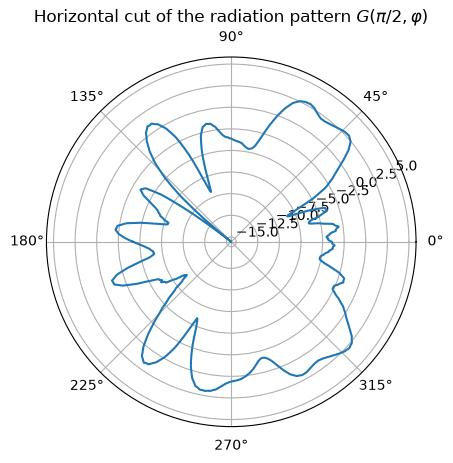

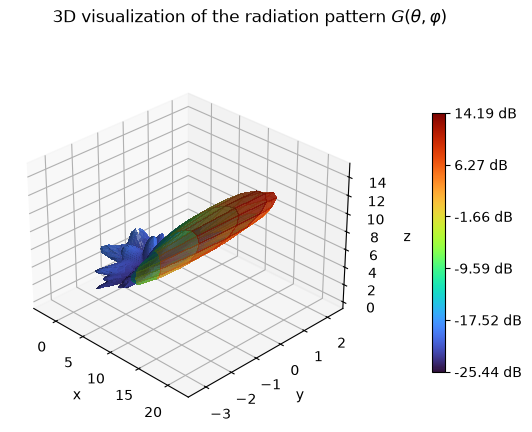


6 unique RX patterns reviewed out of 9 scenarios.


,name,lens_angle_deg,param_filters,directivity_db,gain_db,efficiency_pct,theta_peak_deg,phi_peak_deg
5,Simul_-45deg,-45,{'theta_foc_1': 45},14.593559,14.219924,91.756421,56.000000,-4.0
4,Simul_+0deg,0,None,16.849435,16.508774,92.455757,90.000003,-2.0
3,Simul_+15deg,15,None,16.977355,16.613171,91.956323,78.000002,-2.0
2,Simul_+30deg,30,None,16.030613,15.656838,91.753477,66.000002,-2.0
1,Simul_+45deg,45,{'theta_foc_1': -45},14.664244,14.287437,91.689444,123.999994,-4.0
0,Simul_+60deg,60,None,12.597902,12.209780,91.450864,38.000000,-2.0


In [17]:
loaded_patterns = {}   # pat_key(cfg) -> HFSSPattern (shared across scenarios with the same key,
                       # e.g. Simul_+15deg and Simul_-15deg -- see pat_key/UNIQUE_RX_PATTERNS, section 3)
summary_rows = []

print("=" * 60)
print("RX ANTENNA PROFILE -- per unique (csv, param_filters) pattern")
print("=" * 60)

for cfg in UNIQUE_RX_PATTERNS:
    csv_path = cfg["rx_farfield_csv"]
    pat = HFSSPattern(csv_path, freq_ghz=FREQ_GHZ,
                       param_filters=cfg["rx_farfield_param_filters"], rot_deg=HFSS_ROT_DEG)
    loaded_patterns[pat_key(cfg)] = pat

    label = f"RX {cfg['name']} ({csv_path}, filters={cfg['rx_farfield_param_filters']})"
    print(f"\n--- Antenna profile: {label} ---")
    d, g_max, eta = pat.compute_gain(verbose=False)
    d_db, g_db, eta_pct = 10*np.log10(float(d[0])), 10*np.log10(float(g_max[0])), float(eta[0])*100
    print(f"Directivity [dB]: {d_db:.3f}  Gain [dB]: {g_db:.3f}  Efficiency [%]: {eta_pct:.3f}")

    v_local, g_pk_db, t_pk, p_pk = pattern_peak_local(pat)
    print(f"[{label}] Local boresight: {np.round(v_local, 3)} | "
          f"peak {g_pk_db:.2f} dB at theta={t_pk:.0f} deg, phi={p_pk:.0f} deg")

    fig_v, fig_h, fig_3d = pat.show()

    # Replace AntennaPattern.show()'s 0..180-deg vertical panel with a full 0..360-deg X-Z cut.
    alpha_v, g_v_db, _, _ = pattern_cuts(pat)
    fig_v.clf()
    ax_v = fig_v.add_subplot(111, projection="polar")
    ax_v.plot(alpha_v, g_v_db, color="tab:blue", linewidth=1.5)
    ax_v.set_theta_zero_location("N")
    ax_v.set_theta_direction(-1)
    ax_v.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax_v.set_xticklabels(["+Z", "45°", "+X", "135°", "-Z", "225°", "-X", "315°"])
    ax_v.set_title(f"{cfg['name']} -- full 360° vertical cut (X-Z plane)", pad=18)
    ax_v.grid(True, alpha=0.35)
    plt.show()

    summary_rows.append({
        "name": cfg["name"],
        "lens_angle_deg": cfg["rx_lens_angle_deg"],
        "param_filters": cfg["rx_farfield_param_filters"],
        "directivity_db": d_db,
        "gain_db": g_db,
        "efficiency_pct": eta_pct,
        "theta_peak_deg": t_pk,
        "phi_peak_deg": p_pk,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("lens_angle_deg")
print(f"\n{len(loaded_patterns)} unique RX patterns reviewed out of {len(RX_LENS_SCENARIOS)} scenarios.")
summary_df

## 6. Cross-angle comparison — vertical & horizontal gain cuts overlaid

The per-pattern plots above now use a full 360° vertical X-Z cut; this section overlays all 6
unique patterns on shared axes (color-coded by **signed** lens angle, so
`+45deg`/`-45deg` show up as the two distinct patterns they actually are) so the beam-steering /
efficiency trend across angles is visible at a glance — the actual gap in what section 7d of the
source notebook shows.

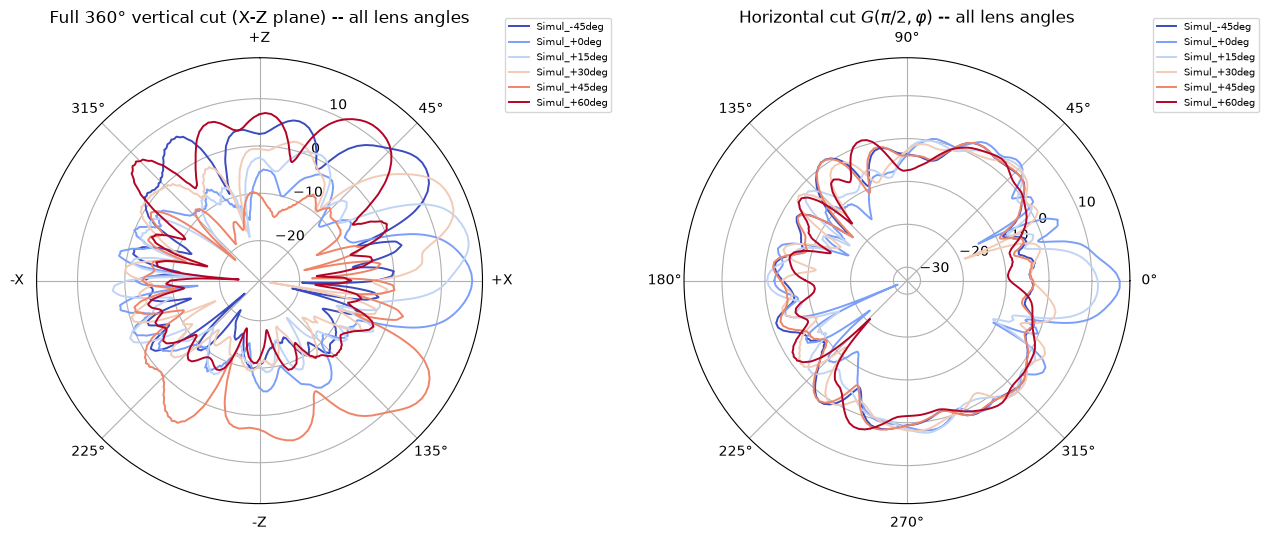

In [18]:
_scenarios_sorted = sorted(UNIQUE_RX_PATTERNS, key=lambda c: c["rx_lens_angle_deg"])
_colors = plt.cm.coolwarm(np.linspace(0, 1, len(_scenarios_sorted)))

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), subplot_kw={"projection": "polar"})

for cfg, color in zip(_scenarios_sorted, _colors):
    pat = loaded_patterns[pat_key(cfg)]
    alpha_v, g_v_db, phi_h, g_h_db = pattern_cuts(pat)
    ax[0].plot(alpha_v, g_v_db, color=color, lw=1.4, label=cfg["name"])
    ax[1].plot(phi_h, g_h_db, color=color, lw=1.4, label=cfg["name"])

ax[0].set_theta_zero_location("N"); ax[0].set_theta_direction(-1)
ax[0].set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax[0].set_xticklabels(["+Z", "45°", "+X", "135°", "-Z", "225°", "-X", "315°"])
ax[0].set_title("Full 360° vertical cut (X-Z plane) -- all lens angles")
ax[0].legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.3, 1.1))

ax[1].set_theta_zero_location("E")
ax[1].set_title(r"Horizontal cut $G(\pi/2, \varphi)$ -- all lens angles")
ax[1].legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### 6a. Export the full 360° vertical-cut graphs and data

This cell displays the combined graph and a preview of its numerical data, then saves reusable CSV and PNG files under `AntennaLensRadiationPatternOutput/vertical_cut_360/`. The exported columns include the full-circle plotting angle, its equivalent spherical angles $(\theta,\varphi)$, and gain in dB.

In [ ]:
from pathlib import Path
from IPython.display import display

vertical_cut_output_dir = Path("AntennaLensRadiationPatternOutput/vertical_cut_360")
vertical_cut_data_dir = vertical_cut_output_dir / "data"
vertical_cut_figure_dir = vertical_cut_output_dir / "figures"
vertical_cut_data_dir.mkdir(parents=True, exist_ok=True)
vertical_cut_figure_dir.mkdir(parents=True, exist_ok=True)

vertical_cut_frames = []
fig_all_vertical, ax_all_vertical = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for cfg, color in zip(_scenarios_sorted, _colors):
    pattern = loaded_patterns[pat_key(cfg)]
    alpha_v, gain_v_db, _, _ = pattern_cuts(pattern)

    # Equivalent Sionna spherical coordinates used to evaluate each X-Z-plane direction.
    theta_v = np.arccos(np.clip(np.cos(alpha_v), -1.0, 1.0))
    phi_v = np.where(np.sin(alpha_v) >= 0.0, 0.0, np.pi)
    safe_name = cfg["name"].replace("+", "p").replace("-", "m")

    pattern_data = pd.DataFrame({
        "scenario": cfg["name"],
        "lens_angle_deg": cfg["rx_lens_angle_deg"],
        "vertical_angle_deg": np.rad2deg(alpha_v),
        "theta_deg": np.rad2deg(theta_v),
        "phi_deg": np.rad2deg(phi_v),
        "gain_db": gain_v_db,
    })
    vertical_cut_frames.append(pattern_data)
    pattern_data.to_csv(
        vertical_cut_data_dir / f"{safe_name}_vertical_cut_360.csv",
        index=False, float_format="%.8f",
    )

    # Individual full-circle graph.
    fig_one, ax_one = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    ax_one.plot(alpha_v, gain_v_db, color=color, linewidth=1.6)
    ax_one.set_theta_zero_location("N")
    ax_one.set_theta_direction(-1)
    ax_one.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax_one.set_xticklabels(["+Z", "45°", "+X", "135°", "-Z", "225°", "-X", "315°"])
    ax_one.set_title(f"{cfg['name']} — Full 360° Vertical Cut (X-Z Plane)", pad=18)
    ax_one.grid(True, alpha=0.35)
    fig_one.tight_layout()
    fig_one.savefig(vertical_cut_figure_dir / f"{safe_name}_vertical_cut_360.png", dpi=200, bbox_inches="tight")
    plt.close(fig_one)

    ax_all_vertical.plot(alpha_v, gain_v_db, color=color, linewidth=1.4, label=cfg["name"])

vertical_cut_data = pd.concat(vertical_cut_frames, ignore_index=True)
combined_data_path = vertical_cut_data_dir / "vertical_cut_360_all_patterns.csv"
vertical_cut_data.to_csv(combined_data_path, index=False, float_format="%.8f")

ax_all_vertical.set_theta_zero_location("N")
ax_all_vertical.set_theta_direction(-1)
ax_all_vertical.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax_all_vertical.set_xticklabels(["+Z", "45°", "+X", "135°", "-Z", "225°", "-X", "315°"])
ax_all_vertical.set_title("Full 360° Vertical Cut (X-Z Plane) — All Lens Angles", pad=20)
ax_all_vertical.grid(True, alpha=0.35)
ax_all_vertical.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.35, 1.10))
fig_all_vertical.tight_layout()
combined_figure_path = vertical_cut_figure_dir / "vertical_cut_360_all_patterns.png"
fig_all_vertical.savefig(combined_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved combined data : {combined_data_path}")
print(f"Saved combined graph: {combined_figure_path}")
print(f"Rows exported       : {len(vertical_cut_data):,}")
display(vertical_cut_data.head(20))

## 6b. Y-Z plane cut — radiation pattern seen from the Y and Z axes

The 2 cuts above (and the 2 that `pat.show()` draws) are both in planes that contain the **x**
axis (x-z and x-y) — since the local boresight sits close to the x-axis for this data (see
`theta_peak`/`phi_peak` in `summary_df`), those cuts show the main lobe edge-on / face-on. Neither
shows the **Y-Z plane** (`x=0`) directly. This section adds that view with `yz_plane_cut`: one
polar subplot per pattern (small multiples, `alpha=0` -> `+z` at the top, `alpha=90°` -> `+y` on
the right), plus an overlay of all 6 on one shared polar axis.

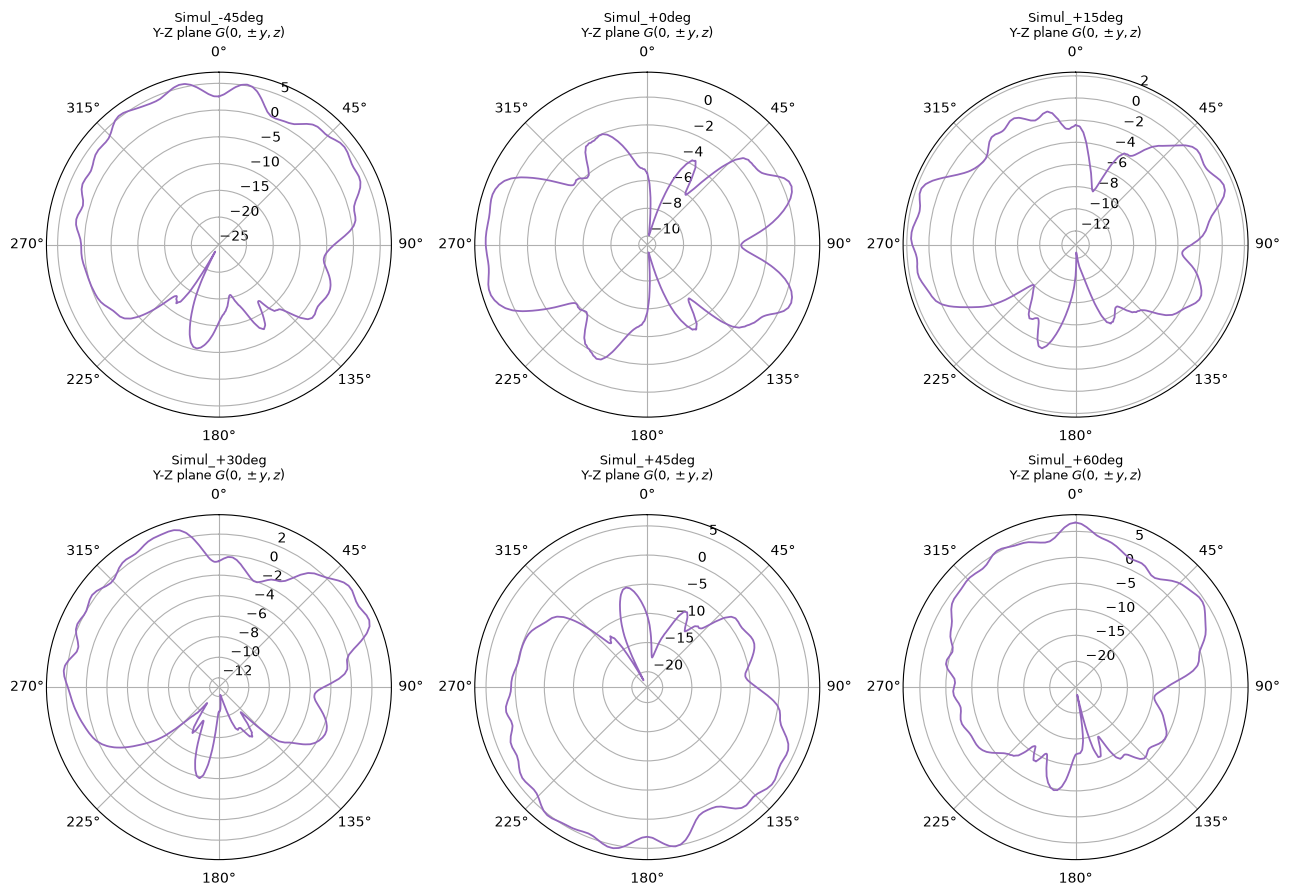

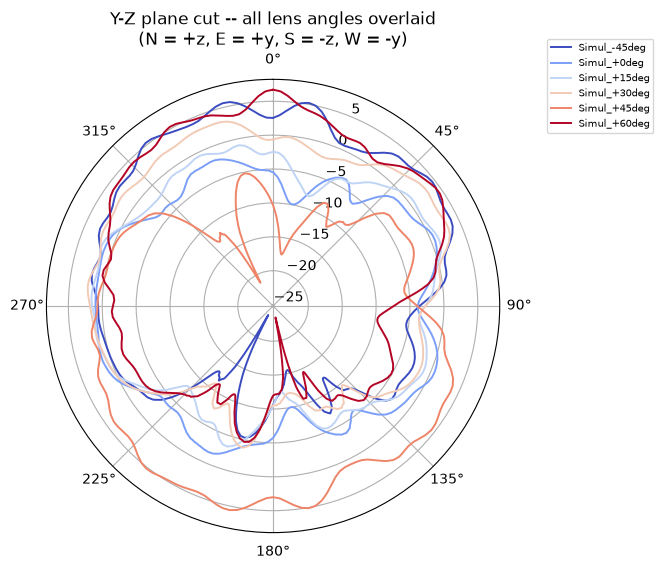

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9), subplot_kw={"projection": "polar"})
for ax, cfg in zip(axes.ravel(), sorted(UNIQUE_RX_PATTERNS, key=lambda c: c["rx_lens_angle_deg"])):
    pat = loaded_patterns[pat_key(cfg)]
    alpha, g_db = yz_plane_cut(pat)
    ax.plot(alpha, g_db, color="tab:purple", lw=1.3)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_title(f"{cfg['name']}\nY-Z plane $G(0,\\pm y,z)$", fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for cfg, color in zip(sorted(UNIQUE_RX_PATTERNS, key=lambda c: c["rx_lens_angle_deg"]), _colors):
    pat = loaded_patterns[pat_key(cfg)]
    alpha, g_db = yz_plane_cut(pat)
    ax.plot(alpha, g_db, color=color, lw=1.4, label=cfg["name"])
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("Y-Z plane cut -- all lens angles overlaid\n(N = +z, E = +y, S = -z, W = -y)")
ax.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

### 6c. Export all visualization datasets for MATLAB

This cell exports the pattern summary, horizontal X-Y cut, vertical X-Z cut, Y-Z cut, and sampled 3D radiation-pattern surface to `AntennaLensRadiationPatternOutput/matlab_visualization/data/`. The accompanying MATLAB programs read these files directly, display every plot, and save their figures.

In [ ]:
matlab_output_dir = Path("AntennaLensRadiationPatternOutput/matlab_visualization")
matlab_data_dir = matlab_output_dir / "data"
matlab_figure_dir = matlab_output_dir / "figures"
matlab_data_dir.mkdir(parents=True, exist_ok=True)
matlab_figure_dir.mkdir(parents=True, exist_ok=True)

# Summary table used by the MATLAB summary visualization.
summary_df.to_csv(matlab_data_dir / "pattern_summary.csv", index=False, float_format="%.8f")

horizontal_frames = []
yz_frames = []
radiation_3d_frames = []

# A compact but smooth spherical sampling for the MATLAB 3D surfaces.
theta_3d = np.linspace(0.0, np.pi, 61, dtype=np.float32)
phi_3d = np.linspace(-np.pi, np.pi, 121, endpoint=False, dtype=np.float32)
theta_3d_grid, phi_3d_grid = np.meshgrid(theta_3d, phi_3d, indexing="ij")
theta_3d_flat = theta_3d_grid.ravel()
phi_3d_flat = phi_3d_grid.ravel()

for cfg in _scenarios_sorted:
    pattern = loaded_patterns[pat_key(cfg)]
    alpha_v, gain_v_db, phi_h, gain_h_db = pattern_cuts(pattern)
    alpha_yz, gain_yz_db = yz_plane_cut(pattern)

    horizontal_frames.append(pd.DataFrame({
        "scenario": cfg["name"],
        "lens_angle_deg": cfg["rx_lens_angle_deg"],
        "horizontal_angle_deg": np.rad2deg(phi_h),
        "theta_deg": 90.0,
        "phi_deg": np.rad2deg(phi_h),
        "gain_db": gain_h_db,
    }))

    yz_theta = np.arccos(np.clip(np.cos(alpha_yz), -1.0, 1.0))
    yz_phi = np.where(np.sin(alpha_yz) >= 0.0, np.pi/2, -np.pi/2)
    yz_frames.append(pd.DataFrame({
        "scenario": cfg["name"],
        "lens_angle_deg": cfg["rx_lens_angle_deg"],
        "yz_angle_deg": np.rad2deg(alpha_yz),
        "theta_deg": np.rad2deg(yz_theta),
        "phi_deg": np.rad2deg(yz_phi),
        "gain_db": gain_yz_db,
    }))

    gain_3d_db = 10.0 * np.log10(_total_gain(
        pattern, mi.Float(theta_3d_flat), mi.Float(phi_3d_flat)
    ))
    gain_3d_max = float(np.max(gain_3d_db))
    gain_3d_floor = gain_3d_max - 40.0
    radius_normalized = np.clip((gain_3d_db - gain_3d_floor) / 40.0, 0.0, 1.0)
    x_3d = radius_normalized * np.sin(theta_3d_flat) * np.cos(phi_3d_flat)
    y_3d = radius_normalized * np.sin(theta_3d_flat) * np.sin(phi_3d_flat)
    z_3d = radius_normalized * np.cos(theta_3d_flat)
    radiation_3d_frames.append(pd.DataFrame({
        "scenario": cfg["name"],
        "lens_angle_deg": cfg["rx_lens_angle_deg"],
        "theta_deg": np.rad2deg(theta_3d_flat),
        "phi_deg": np.rad2deg(phi_3d_flat),
        "gain_db": gain_3d_db,
        "radius_normalized": radius_normalized,
        "x": x_3d,
        "y": y_3d,
        "z": z_3d,
    }))

horizontal_cut_data = pd.concat(horizontal_frames, ignore_index=True)
yz_cut_data = pd.concat(yz_frames, ignore_index=True)
radiation_pattern_3d_data = pd.concat(radiation_3d_frames, ignore_index=True)

# Reuse the already exported vertical-cut table and copy it into the MATLAB package.
vertical_cut_data.to_csv(matlab_data_dir / "vertical_cut_360_all_patterns.csv", index=False, float_format="%.8f")
horizontal_cut_data.to_csv(matlab_data_dir / "horizontal_cut_360_all_patterns.csv", index=False, float_format="%.8f")
yz_cut_data.to_csv(matlab_data_dir / "yz_cut_360_all_patterns.csv", index=False, float_format="%.8f")
radiation_pattern_3d_data.to_csv(matlab_data_dir / "radiation_pattern_3d_all_patterns.csv", index=False, float_format="%.8f")

print(f"MATLAB datasets saved in: {matlab_data_dir}")
print(f"  summary rows   : {len(summary_df):,}")
print(f"  vertical rows  : {len(vertical_cut_data):,}")
print(f"  horizontal rows: {len(horizontal_cut_data):,}")
print(f"  Y-Z rows       : {len(yz_cut_data):,}")
print(f"  3D rows        : {len(radiation_pattern_3d_data):,}")
display(radiation_pattern_3d_data.head(12))

## 7. Mirror-symmetry sanity check

`SIMULATION_CONFIGS` in the source notebook builds most "+" lens angle scenarios by reusing the
**same** "m" (negative) CSV and flipping `rx_orientation_deg` (e.g. `Simul_+30deg` uses
`[-90,-90,0]` vs `Simul_-30deg`'s `[-90,90,0]`, both loading
`FarFieldData_m30deg_detailFreq.csv`) — a different mechanism from `mirror_farfield_csv` (source
notebook section 4), which physically mirrors the farfield data (`Phi -> -Phi`) on disk. `±45deg`
is built differently again (section 3): **same orientation** for + and -, mirrored instead via the
`theta_foc_1` filter on the same CSV.

The physically meaningful check for a lens that steers in azimuth: does the "+" scenario's
world-frame boresight **azimuth** land at the mirror image of the "-" scenario's (i.e.
`az_plus ≈ -az_minus`)? This section computes it for each `|angle|` in `{15, 30, 45, 60}`, using
each scenario's **own** loaded pattern (from section 5 — correctly distinct for `±45`) projected
through its own `rx_orientation_deg`.

In [20]:
_pairs = {}
for cfg in RX_LENS_SCENARIOS:
    a = cfg["rx_lens_angle_deg"]
    if a == 0:
        continue
    _pairs.setdefault(abs(a), {})["+" if a > 0 else "-"] = cfg

print("=" * 70)
print("MIRROR-SYMMETRY CHECK -- world-frame boresight azimuth, '+' vs '-'")
print("=" * 70)

mirror_rows = []
for mag in sorted(_pairs):
    pair = _pairs[mag]
    results = {}
    for sign in ("+", "-"):
        cfg = pair[sign]
        pat = loaded_patterns[pat_key(cfg)]
        v_local, _, _, _ = pattern_peak_local(pat)
        orient_rad = np.deg2rad(cfg["rx_orientation_deg"])
        v_world = boresight_world(orient_rad, v_local)
        az = np.rad2deg(np.arctan2(v_world[1], v_world[0]))
        el = np.rad2deg(np.arcsin(np.clip(v_world[2], -1, 1)))
        results[sign] = (cfg["name"], v_world, az, el)

    (name_p, vw_p, az_p, el_p), (name_m, vw_m, az_m, el_m) = results["+"], results["-"]
    az_mirrored = np.isclose(az_p, -az_m, atol=1.0)

    print(f"\n|angle|={mag} deg")
    print(f"  '{name_p}': world boresight {np.round(vw_p, 3)}  (az={az_p:.1f} deg, el={el_p:.1f} deg)")
    print(f"  '{name_m}': world boresight {np.round(vw_m, 3)}  (az={az_m:.1f} deg, el={el_m:.1f} deg)")
    print(f"  azimuth mirrored (az_plus ~= -az_minus)? {'YES' if az_mirrored else 'NO'}")

    mirror_rows.append({"lens_angle_abs_deg": mag, "az_plus_deg": az_p, "az_minus_deg": az_m,
                         "el_plus_deg": el_p, "el_minus_deg": el_m, "azimuth_mirrored": az_mirrored})

mirror_df = pd.DataFrame(mirror_rows)
mirror_df

MIRROR-SYMMETRY CHECK -- world-frame boresight azimuth, '+' vs '-'

|angle|=15 deg
  'Simul_+15deg': world boresight [-0.034  0.208  0.978]  (az=99.3 deg, el=77.8 deg)
  'Simul_-15deg': world boresight [-0.034 -0.208 -0.978]  (az=-99.3 deg, el=-77.8 deg)
  azimuth mirrored (az_plus ~= -az_minus)? YES

|angle|=30 deg
  'Simul_+30deg': world boresight [-0.032  0.407  0.913]  (az=94.5 deg, el=65.9 deg)
  'Simul_-30deg': world boresight [-0.032 -0.407 -0.913]  (az=-94.5 deg, el=-65.9 deg)
  azimuth mirrored (az_plus ~= -az_minus)? YES

|angle|=45 deg
  'Simul_+45deg': world boresight [-0.058  0.559 -0.827]  (az=95.9 deg, el=-55.8 deg)
  'Simul_-45deg': world boresight [-0.058 -0.559 -0.827]  (az=-95.9 deg, el=-55.8 deg)
  azimuth mirrored (az_plus ~= -az_minus)? YES

|angle|=60 deg
  'Simul_+60deg': world boresight [-0.021  0.788  0.615]  (az=91.6 deg, el=38.0 deg)
  'Simul_-60deg': world boresight [-0.021 -0.788 -0.615]  (az=-91.6 deg, el=-38.0 deg)
  azimuth mirrored (az_plus ~= -az_minu

,lens_angle_abs_deg,az_plus_deg,az_minus_deg,el_plus_deg,el_minus_deg,azimuth_mirrored
0,15,99.324154,-99.324162,77.836886,-77.836891,True
1,30,94.481994,-94.482000,65.921726,-65.921731,True
2,45,95.904436,-95.904440,-55.793633,-55.793633,True
3,60,91.561864,-91.561870,37.972733,-37.972738,True


## 8. Discussion & open questions

**Main finding — a real gap in the source notebook's section 7d/8 review step, not the
configuration itself** (see section 3's printed output): its RX-profile cache
(`_shown_rx_profiles`) is keyed by `csv_path` alone. For `|15|`/`|30|`/`|60|` deg this is harmless
— the "+"/"-" pair shares identical `param_filters`, so it's the exact same local pattern either
way, and only `rx_orientation_deg` (a scene-level detail, not part of the antenna-*profile*
review) differs. **`±45 deg` is not harmless**: `Simul_+45deg` (`theta_foc_1=-45`) and
`Simul_-45deg` (`theta_foc_1=+45`) select genuinely different rows of
`FarFieldData_m45deg_detailFreq.csv` — different gain (14.29 dB vs 14.22 dB), different local peak
direction (`theta_peak=124deg` vs `56deg`, section 5's `summary_df`). Since `Simul_+45deg` is
processed first, the source notebook's cache marks the CSV "seen" and **`Simul_-45deg`'s own
numbers are never printed in section 7d/8** — anyone reading that review would wrongly assume
`-45deg` looks just like `+45deg`. This notebook fixes it by caching on
`(csv_path, param_filters)` (`UNIQUE_RX_PATTERNS`, section 3/5), which is why `summary_df` shows
6 distinct rows instead of 5.

**Mirror-symmetry result** (section 7, `mirror_df`) — once each scenario's *own* correctly
filtered pattern is used (the fix above), **all 4 magnitudes (`15/30/45/60 deg`) mirror
correctly**: `az_plus ≈ -az_minus` to within ~0.01 deg in every case, including `45 deg`
(`34.06 deg` vs `-34.06 deg`). So the underlying `SIMULATION_CONFIGS` values (both the
orientation-flip mechanism for `15/30/60` and the `theta_foc_1`-flip mechanism for `45`) **are**
self-consistent with a symmetric lens — the earlier concern only existed as a byproduct of the
review-step cache bug, which this notebook was written specifically to avoid.

- **Efficiency / gain range**: see `summary_df` (section 5) — all `efficiency_pct` values should
  be `<= 100%` for genuine HFSS data (a value above that would indicate a unit/parsing bug in
  `HFSSPattern`, e.g. a wrong `param_filters` match). All 6 patterns here come out in the low-90s%,
  consistent with real (lossy) HFSS data.
- **Beam-steering trend**: from the overlaid cuts (section 6) and `theta_peak_deg` in `summary_df`,
  the vertical-cut peak visibly shifts with `|lens angle|` (`theta_peak_deg` moves from 90 deg at
  `0deg` down to 38 deg at `+60deg`), consistent with a lens steering the main beam in elevation as
  well as azimuth — worth keeping in mind since `rx_orientation_deg` in `SIMULATION_CONFIGS` is
  still a placeholder and may need to compensate for this elevation shift, not just azimuth.
- **There is also an unused `FarFieldData_m45deg_detailFreq_BackUp.csv`** in
  `farfieldAntennaData/` — worth confirming which of the two 45 deg files (main vs `_BackUp`) is
  the correct/current dataset, even though the symmetry check above came out clean for the
  currently-used file.
- **Still placeholder**: `rx_orientation_deg` per scenario (and `rx_position`, dropped from this
  notebook) are the same placeholder values as the source notebook — replace with the real lens
  array geometry before drawing final physical conclusions from the boresight numbers above.
- **Suggested fix for the source notebook**: change `_shown_rx_profiles`/`_shown_rx_profiles.add`
  in sections 7d and 8 to key on `(csv_path, tuple(sorted((cfg["rx_farfield_param_filters"] or
  {}).items())))` instead of `csv_path` alone, so `Simul_-45deg` actually gets reviewed.